In [2]:
import os
import sys
import json

import numpy as np
import pandas as pd
import torch
import scanpy as sc
import matplotlib
#matplotlib.use("Agg")
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, linregress

SCRIPT_DIR = '.'
REPO_ROOT = os.path.abspath(os.path.join(SCRIPT_DIR, "..", ".."))
sys.path.append(os.path.join(REPO_ROOT, "scripts"))

from train_loo import preprocess_crc, preprocess_spatial_features, _load_model  # noqa: E402
from counterfactual_analysis import get_lfc, _to_dense, _normalize_counts, safe_log2_fold_change  # noqa: E402
from configs.adata_crc_config import ADATA_ARGS  # noqa: E402
from utils import set_seed  # noqa: E402
from cellina import make_counterfactual_adata  # noqa: E402

/data/a330d/miniforge3/envs/cellina-graph/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [54]:
# --------------------------------------------------------------------------
# Config
# --------------------------------------------------------------------------
DATA_ROOT = "/data2/a330d"
SLIDE_ID = "crc_231"
HOLDOUT_CELLTYPE = "Fibroblast"
ADATA_PATH = os.path.join(DATA_ROOT, "datasets/crc/raw_zenodo", f"{SLIDE_ID}.h5ad")
MODEL_ROOT = os.path.join(DATA_ROOT, "data/ood/trained")
MODEL_SAVE_DIR = os.path.join(MODEL_ROOT, SLIDE_ID, HOLDOUT_CELLTYPE, "cellina-W_1")

N_DEG = 50
BATCH_SIZE = 1024
LIBRARY_SIZE = "latent"
STEP_SIZE_PX = 0.12028

# Nested sampling budget. At ~1s/forward-call (precomputed=True donor
# resampling, see note below) the full script runs in ~5-10 minutes.
N_NICHES = 20             # OUTER draws: distinct donor-niche assignments
N_ZS_PER_NICHE = 6        # INNER draws per niche: fresh z,s at fixed niche
N_NB_DRAWS = 25           # extra NB-emission-noise draws at one fixed (niche, z, s)
CALIB_LEVELS = [0.5, 0.8, 0.9, 0.95]

# Analysis 2 (per-cell extrapolation check) -- subsampled for tractability;
# reported explicitly rather than silently applied to the full control set.
A2_N_CELLS = 1200
A2_N_REPLICATES = 25

RESULTS_DIR = os.path.join(REPO_ROOT, "results", "uncertainty")
FIGURES_DIR = os.path.join(REPO_ROOT, "figures", "uncertainty")
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

RNG = np.random.default_rng(0)

In [55]:
def banner(title):
    print("\n" + "=" * 78)
    print(title)
    print("=" * 78)

In [56]:
# --------------------------------------------------------------------------
# Setup: data + model
# --------------------------------------------------------------------------
banner("Loading & preprocessing adata")
set_seed(0)

n_top_genes = ADATA_ARGS.get("n_top_genes")
labels_key = ADATA_ARGS.get("labels_key")
domains_key = ADATA_ARGS.get("domains_key")
n_neighbors = ADATA_ARGS.get("n_neighbors")
control_domain = ADATA_ARGS.get("control_domains")[0]
holdout_domain = ADATA_ARGS.get("holdout_domains")[0]

adata = sc.read(ADATA_PATH)
adata = preprocess_crc(adata, n_top_genes=n_top_genes, labels_key=labels_key, domains_key=domains_key)
# test_indices=None: this checkpoint is a shared, whole-slide model (no
# celltype-specific train/test split at train time -- see module docstring),
# so there is no test-set leakage to guard against here.
adata = preprocess_spatial_features(adata, step_size_px=STEP_SIZE_PX, n_neighbors=n_neighbors, test_indices=None)
print(f"adata: {adata.n_obs} cells x {adata.n_vars} genes")


Loading & preprocessing adata


/data/a330d/projects/cellina-reproducibility/scripts/train_loo.py:181: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[labels_key] = adata.obs[labels_key].astype("category")


adata: 246316 cells x 2000 genes


In [57]:
banner("Loading trained Cellina model")
model, _ = _load_model(MODEL_SAVE_DIR, model_class="cellina", adata=adata)
theta = torch.exp(model.module.px_r).detach().cpu().numpy()  # per-gene NB dispersion

is_control_region = adata.obs[domains_key] == control_domain
is_holdout_ct = adata.obs[labels_key].astype(str) == HOLDOUT_CELLTYPE
mask_control = is_control_region & is_holdout_ct
idx_control = np.where(mask_control.values)[0]

is_holdout_region = adata.obs[domains_key].astype(str) == holdout_domain
mask_target = is_holdout_ct & is_holdout_region
idx_target = np.where(mask_target.values)[0]

conn = adata.obsp["spatial_connectivities_orig"]
neighbor_indices = np.unique(conn[idx_target].nonzero()[1])
neighbor_indices = neighbor_indices[~is_holdout_ct.values[neighbor_indices]]

control = _to_dense(adata.layers["counts"][mask_control.values, :])
target = _to_dense(adata.layers["counts"][mask_target.values, :])
print(f"control (REF, {HOLDOUT_CELLTYPE}): {control.shape[0]} cells")
print(f"target  (CRC, {HOLDOUT_CELLTYPE}): {target.shape[0]} cells")
print(f"donor niche pool (CRC, non-{HOLDOUT_CELLTYPE} neighbours): {len(neighbor_indices)} cells")

# gt_vec / deg computed once from real data with the repo's own get_lfc
# (counterfactual=target is a placeholder here; only gt_vec and deg are used).
gt_vec, _, deg = get_lfc(control=control, target=target, counterfactual=target, n_deg=N_DEG)

INFO: Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
2026-07-27 12:05:54 | [INFO] Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.



Loading trained Cellina model
INFO     File /data2/a330d/data/ood/trained/crc_231/Fibroblast/cellina-W_1/model.pt already downloaded             


/data/a330d/miniforge3/envs/cellina-graph/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        
cellina loaded model from /data2/a330d/data/ood/trained/crc_231/Fibroblast/cellina-W_1
control (REF, Fibroblast): 10734 cells
target  (CRC, Fibroblast): 23051 cells
donor niche pool (CRC, non-Fibroblast neighbours): 49828 cells


In [58]:
# --------------------------------------------------------------------------
# Helpers
# --------------------------------------------------------------------------
def population_logfc(counts, control_dense=control):
    """log2 fold change of pseudobulk(counts) vs pseudobulk(control), all genes."""
    counts_n = _normalize_counts(np.asarray(counts))
    control_n = _normalize_counts(control_dense)
    return safe_log2_fold_change(counts_n.mean(axis=0), control_n.mean(axis=0))


def draw_niche(niche_seed):
    """One OUTER (niche) x one INNER (z, s) draw: predicted expression for
    every focal (control) cell under a donor niche assignment sampled with
    ``niche_seed``. z, s are redrawn every call (stochastic encoder); the
    donor assignment is redrawn only when niche_seed changes.

    Uses precomputed=True (sample a donor cell's own precomputed spatial
    feature vector) rather than precomputed=False (rebuild the local
    connectivity graph from scratch), because the analyses below call this
    hundreds of times. A single-draw check (see console output at the top of
    S1) confirms this gives the same Pearson r as precomputed=False.
    """
    return model.get_counterfactual_expression(
        indices=idx_control,
        neighbour_indices=neighbor_indices,
        adata=adata,
        batch_size=BATCH_SIZE,
        seed=niche_seed,
        library_size=LIBRARY_SIZE,
        precomputed=True,
    )


def sample_nb_counts(mu, theta_vec, rng):
    """One draw from NB(mean=mu, dispersion=theta_vec), scvi's NB2 parameterization."""
    mu = np.clip(np.asarray(mu), 1e-8, None)
    theta_b = np.broadcast_to(theta_vec, mu.shape)
    p = theta_b / (theta_b + mu)
    return rng.negative_binomial(theta_b, p).astype(np.float32)


In [59]:
N_NICHES, N_ZS_PER_NICHE

(20, 6)

In [60]:
# --------------------------------------------------------------------------
# S1: does n_outer=1, n_inner=1 reproduce the standard one-shot pipeline?
# --------------------------------------------------------------------------
banner("S1: plumbing sanity check (n_outer=1, n_inner=1)")

torch.manual_seed(12345)
reference_counts = draw_niche(niche_seed=0)
reference_vec = population_logfc(reference_counts)
reference_pear, _ = pearsonr(gt_vec[deg], reference_vec[deg])

torch.manual_seed(12345)
harness_counts = draw_niche(niche_seed=0)
harness_vec = population_logfc(harness_counts)
harness_pear, _ = pearsonr(gt_vec[deg], harness_vec[deg])

s1_max_abs_diff = float(np.max(np.abs(reference_vec - harness_vec)))
s1_pass = np.allclose(reference_vec, harness_vec, atol=1e-5)
print(f"reference call: Pearson r (top {N_DEG} DE genes) = {reference_pear:.4f}")
print(f"harness call (same reseed):                        = {harness_pear:.4f}")
print(f"max abs diff between the two logFC vectors: {s1_max_abs_diff:.2e}")
print(f"S1 {'PASSED' if s1_pass else 'FAILED'}: sampling harness reproduces the plain "
      f"single-draw counterfactual pipeline used elsewhere in this repo.")
if not s1_pass:
    print("STOPPING: S1 failed -- downstream analyses would not be meaningful. "
          "Inspect draw_niche()/population_logfc() before proceeding.")


S1: plumbing sanity check (n_outer=1, n_inner=1)
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/data/a330d/miniforge3/envs/cellina-graph/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
reference call: Pearson r (top 50 DE genes) = 0.3286
harness call (same reseed):                        = 0.3286
max abs diff between the two logFC vectors: 0.00e+00
S1 PASSED: sampling harness reproduces the plain single-draw counterfactual pipeline used elsewhere in this repo.


/data/a330d/miniforge3/envs/cellina-graph/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


In [61]:
# --------------------------------------------------------------------------
# Main nested sampling loop (used by S2, A1, A3, A4, A5)
# --------------------------------------------------------------------------
banner(f"Nested sampling: {N_NICHES} niches x {N_ZS_PER_NICHE} z,s draws (niche varying)")

niche_level_logfc = np.zeros((N_NICHES, gt_vec.shape[0]), dtype=np.float64)
niche_level_logfc_total = np.zeros((N_NICHES, gt_vec.shape[0]), dtype=np.float64)  # NEW: niche + z,s + NB, feeds A3-A5
zs_within_niche_var = np.zeros((N_NICHES, gt_vec.shape[0]), dtype=np.float64)
nb_within_fixed = None

for i, niche_seed in enumerate(range(N_NICHES)):
    zs_draws = np.zeros((N_ZS_PER_NICHE, gt_vec.shape[0]), dtype=np.float64)
    zs_draws_total = np.zeros((N_ZS_PER_NICHE, gt_vec.shape[0]), dtype=np.float64)  # NEW
    for j in range(N_ZS_PER_NICHE):
        counts = draw_niche(niche_seed=niche_seed)
        zs_draws[j] = population_logfc(counts)
        zs_draws_total[j] = population_logfc(sample_nb_counts(counts, theta, RNG))  # NEW: same mean, + NB draw
        if niche_seed == 0 and j == 0:
            # Layer NB emission noise on top of this one fixed (niche, z, s) draw.
            nb_within_fixed = np.zeros((N_NB_DRAWS, gt_vec.shape[0]), dtype=np.float64)
            for k in range(N_NB_DRAWS):
                noisy_counts = sample_nb_counts(counts, theta, RNG)
                nb_within_fixed[k] = population_logfc(noisy_counts)
    niche_level_logfc[i] = zs_draws.mean(axis=0)
    niche_level_logfc_total[i] = zs_draws_total.mean(axis=0)  # NEW
    zs_within_niche_var[i] = zs_draws.var(axis=0, ddof=1)
    print(f"  niche {i + 1}/{N_NICHES} (seed={niche_seed}) done")

banner(f"Nested sampling: {N_NICHES} replicates x {N_ZS_PER_NICHE} z,s draws (niche FROZEN, seed=0)")

frozen_niche_logfc = np.zeros((N_NICHES, gt_vec.shape[0]), dtype=np.float64)
for i in range(N_NICHES):
    zs_draws = np.zeros((N_ZS_PER_NICHE, gt_vec.shape[0]), dtype=np.float64)
    for j in range(N_ZS_PER_NICHE):
        counts = draw_niche(niche_seed=0)  # donor assignment fixed; only z,s vary
        zs_draws[j] = population_logfc(counts)
    frozen_niche_logfc[i] = zs_draws.mean(axis=0)
    print(f"  frozen replicate {i + 1}/{N_NICHES} done")


Nested sampling: 20 niches x 6 z,s draws (niche varying)
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/data/a330d/miniforge3/envs/cellina-graph/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/data/a330d/miniforge3/envs/cellina-graph/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


...

/data/a330d/miniforge3/envs/cellina-graph/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/data/a330d/miniforge3/envs/cellina-graph/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
  frozen replicate 20/20 done


/data/a330d/miniforge3/envs/cellina-graph/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


In [62]:
# --------------------------------------------------------------------------
# S2: freezing the donor niche should collapse the spread ~3-10x
# --------------------------------------------------------------------------
banner("S2: does freezing the donor niche collapse the spread?")

spread_varying = niche_level_logfc[:, deg].std(axis=0, ddof=1).mean()
spread_frozen = frozen_niche_logfc[:, deg].std(axis=0, ddof=1).mean()
s2_ratio = spread_varying / spread_frozen if spread_frozen > 0 else np.inf
print(f"mean per-gene std across {N_NICHES} replicates, top {N_DEG} DE genes:")
print(f"  niche varying: {spread_varying:.4f}")
print(f"  niche frozen : {spread_frozen:.4f}")
print(f"  ratio        : {s2_ratio:.2f}x "
      f"({'within' if 3 <= s2_ratio <= 10 else 'outside'} the ~3-10x range the plan expects)")


S2: does freezing the donor niche collapse the spread?
mean per-gene std across 20 replicates, top 50 DE genes:
  niche varying: 0.0041
  niche frozen : 0.0017
  ratio        : 2.33x (outside the ~3-10x range the plan expects)


In [63]:
V_niche_gene = niche_level_logfc.var(axis=0, ddof=1)         # across-niche variance of niche means
V_zs_gene = zs_within_niche_var.mean(axis=0)                  # avg within-niche variance across z,s
V_nb_gene = nb_within_fixed.var(axis=0, ddof=1)               # variance from NB noise at one fixed (niche, z, s)

V_niche = float(V_niche_gene[deg].mean())
V_zs = float(V_zs_gene[deg].mean())
V_nb = float(V_nb_gene[deg].mean())

V_niche, V_zs

(2.394077890257545e-05, 2.5298705415874562e-05)


Analysis 1: where does the uncertainty come from?
mean per-gene variance (top 50 DE genes):
  niche choice     : 0.00002  (0.2%)
  z,s latent draws : 0.00003  (0.2%)
  NB emission noise: 0.01383  (99.6%, from one fixed niche/z/s draw)


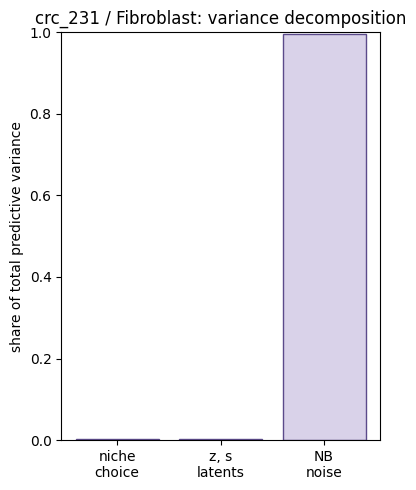

In [64]:
# --------------------------------------------------------------------------
# Analysis 1: variance decomposition (niche | z,s | NB noise)
# --------------------------------------------------------------------------
banner("Analysis 1: where does the uncertainty come from?")

V_niche_gene = niche_level_logfc.var(axis=0, ddof=1)         # across-niche variance of niche means
V_zs_gene = zs_within_niche_var.mean(axis=0)                  # avg within-niche variance across z,s
V_nb_gene = nb_within_fixed.var(axis=0, ddof=1)               # variance from NB noise at one fixed (niche, z, s)

V_niche = float(V_niche_gene[deg].mean())
V_zs = float(V_zs_gene[deg].mean())
V_nb = float(V_nb_gene[deg].mean())
total_V = V_niche + V_zs + V_nb
props = {"niche_choice": V_niche / total_V, "z_s_latents": V_zs / total_V, "nb_emission_noise": V_nb / total_V}

print(f"mean per-gene variance (top {N_DEG} DE genes):")
print(f"  niche choice     : {V_niche:.5f}  ({props['niche_choice']:.1%})")
print(f"  z,s latent draws : {V_zs:.5f}  ({props['z_s_latents']:.1%})")
print(f"  NB emission noise: {V_nb:.5f}  ({props['nb_emission_noise']:.1%}, from one fixed niche/z/s draw)")

fig, ax = plt.subplots(figsize=(4, 5))
labels = ["niche\nchoice", "z, s\nlatents", "NB\nnoise"]
values = [props["niche_choice"], props["z_s_latents"], props["nb_emission_noise"]]
ax.bar(labels, values, color=["#8172B2", "#B5A9D6", "#D9D2E9"], edgecolor="#5B4A8A")
ax.set_ylabel("share of total predictive variance")
ax.set_ylim(0, 1)
ax.set_title(f"{SLIDE_ID} / {HOLDOUT_CELLTYPE}: variance decomposition")
plt.tight_layout()
plt.show()
#fig.savefig(os.path.join(FIGURES_DIR, f"{SLIDE_ID}_{HOLDOUT_CELLTYPE}_variance_decomposition.png"), dpi=200)
plt.close(fig)


Analysis 1: where does the uncertainty come from?
mean per-gene variance (top 50 DE genes):
  niche choice     : 0.00002  (48.6%)
  z,s latent draws : 0.00003  (51.4%)


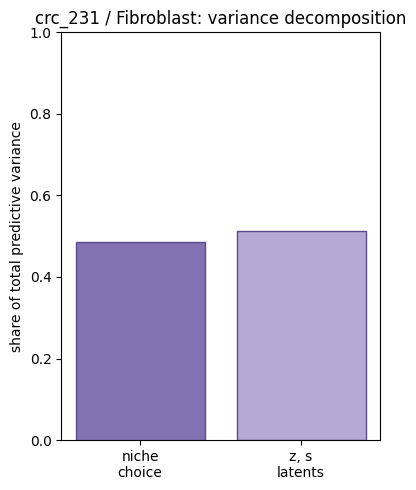

In [65]:
# --------------------------------------------------------------------------
# Analysis 1: variance decomposition (niche | z,s | NB noise)
# --------------------------------------------------------------------------
banner("Analysis 1: where does the uncertainty come from?")

V_niche_gene = niche_level_logfc.var(axis=0, ddof=1)         # across-niche variance of niche means
V_zs_gene = zs_within_niche_var.mean(axis=0)                  # avg within-niche variance across z,s
V_nb_gene = nb_within_fixed.var(axis=0, ddof=1)               # variance from NB noise at one fixed (niche, z, s)

V_niche = float(V_niche_gene[deg].mean())
V_zs = float(V_zs_gene[deg].mean())
V_nb = float(V_nb_gene[deg].mean())
total_V = V_niche + V_zs #+ V_nb
props = {"niche_choice": V_niche / total_V, "z_s_latents": V_zs / total_V}

print(f"mean per-gene variance (top {N_DEG} DE genes):")
print(f"  niche choice     : {V_niche:.5f}  ({props['niche_choice']:.1%})")
print(f"  z,s latent draws : {V_zs:.5f}  ({props['z_s_latents']:.1%})")
#print(f"  NB emission noise: {V_nb:.5f}  ({props['nb_emission_noise']:.1%}, from one fixed niche/z/s draw)")

fig, ax = plt.subplots(figsize=(4, 5))
labels = ["niche\nchoice", "z, s\nlatents"]
values = [props["niche_choice"], props["z_s_latents"]]
ax.bar(labels, values, color=["#8172B2", "#B5A9D6"], edgecolor="#5B4A8A")
ax.set_ylabel("share of total predictive variance")
ax.set_ylim(0, 1)
ax.set_title(f"{SLIDE_ID} / {HOLDOUT_CELLTYPE}: variance decomposition")
plt.tight_layout()
plt.show()
#fig.savefig(os.path.join(FIGURES_DIR, f"{SLIDE_ID}_{HOLDOUT_CELLTYPE}_variance_decomposition.png"), dpi=200)
plt.close(fig)

In [66]:
# --------------------------------------------------------------------------
# Analysis 2: does uncertainty grow with extrapolation distance?
# --------------------------------------------------------------------------
banner("Analysis 2: sigma vs. extrapolation distance")

n_a2 = min(A2_N_CELLS, len(idx_control))
sub_idx = RNG.choice(idx_control, size=n_a2, replace=False)
sub_idx.sort()
print(f"using a subsample of {n_a2}/{len(idx_control)} control cells for tractability")

own_feat = np.asarray(adata.obsm["spatial_x"][sub_idx].todense())
dist_replicates = np.zeros((A2_N_REPLICATES, n_a2))
pred_replicates = np.zeros((A2_N_REPLICATES, n_a2, N_DEG), dtype=np.float32)

for r in range(A2_N_REPLICATES):
    adata_cf = make_counterfactual_adata(
        adata, indices_basal=sub_idx, indices_counterfactual=neighbor_indices,
        spatial_column="spatial_x", precomputed=True, random_state=r,
    )
    transplanted_feat = np.asarray(adata_cf.obsm["spatial_x"].todense())
    dist_replicates[r] = np.linalg.norm(own_feat - transplanted_feat, axis=1)

    px_rate = model.get_normalized_expression(
        adata=adata_cf, indices=None, batch_size=BATCH_SIZE, library_size=LIBRARY_SIZE,
    )
    pred_replicates[r] = px_rate[:, deg]
    print(f"  A2 replicate {r + 1}/{A2_N_REPLICATES} done")

mean_dist = dist_replicates.mean(axis=0)
sigma = pred_replicates.std(axis=0).mean(axis=1)  # per-cell: std across replicates, avg over DEG genes

rho_sigma_dist, p_sigma_dist = spearmanr(mean_dist, sigma)
print(f"per-cell Spearman(sigma, extrapolation distance) = {rho_sigma_dist:.3f} (p={p_sigma_dist:.2e})")


Analysis 2: sigma vs. extrapolation distance
using a subsample of 1200/10734 control cells for tractability


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
  A2 replicate 1/25 done
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/data/a330d/miniforge3/envs/cellina-graph/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)
/data/a330d/miniforge3/envs/cellina-graph/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


  A2 replicate 2/25 done
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
  A2 replicate 3/25 done


/data/a330d/miniforge3/envs/cellina-graph/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


...

/data/a330d/miniforge3/envs/cellina-graph/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)
/data/a330d/miniforge3/envs/cellina-graph/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


  A2 replicate 23/25 done
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
  A2 replicate 24/25 done
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/data/a330d/miniforge3/envs/cellina-graph/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


  A2 replicate 25/25 done
per-cell Spearman(sigma, extrapolation distance) = -0.017 (p=5.50e-01)


/data/a330d/miniforge3/envs/cellina-graph/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


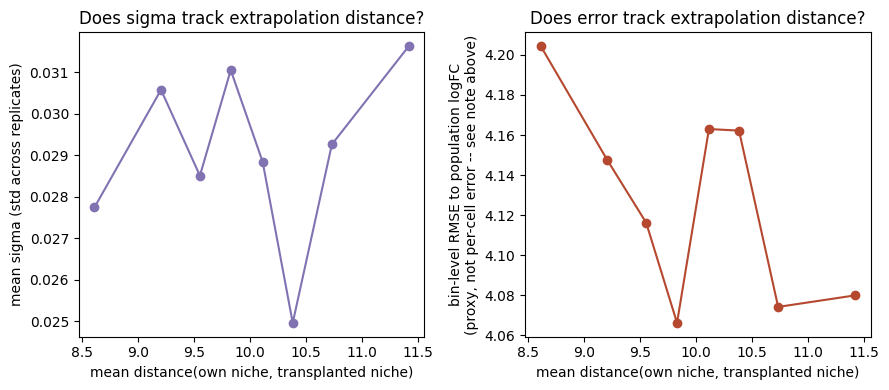

In [67]:
# Bin cells by distance decile. Per bin: mean sigma, and a bin-level *error
# proxy* -- RMSE of that bin's pseudobulk predicted logFC (pooled across
# cells and replicates) against the real population logFC (gt_vec[deg]).
# This is NOT a per-cell error: as the reviewer plan notes explicitly (see
# module docstring / "what we are not doing"), no spatial assay gives a
# matched pre/post measurement of the same cell, so no true per-cell ground
# truth exists. This proxy stays at the population level within each bin.
n_bins = 8
bin_edges = np.quantile(mean_dist, np.linspace(0, 1, n_bins + 1))
bin_edges[-1] += 1e-6
bin_idx = np.digitize(mean_dist, bin_edges[1:-1])

bin_mean_dist, bin_mean_sigma, bin_error = [], [], []
for b in range(n_bins):
    cells_in_bin = np.where(bin_idx == b)[0]
    if len(cells_in_bin) == 0:
        continue
    bin_mean_dist.append(mean_dist[cells_in_bin].mean())
    bin_mean_sigma.append(sigma[cells_in_bin].mean())
    pooled_pred = pred_replicates[:, cells_in_bin, :].reshape(-1, N_DEG)
    control_deg_mean = _normalize_counts(control)[:, deg].mean(axis=0)
    pooled_pred_n = _normalize_counts(pooled_pred)
    bin_logfc = safe_log2_fold_change(pooled_pred_n.mean(axis=0), control_deg_mean)
    bin_error.append(float(np.sqrt(np.mean((bin_logfc - gt_vec[deg]) ** 2))))

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].plot(bin_mean_dist, bin_mean_sigma, "o-", color="#8172B2")
axes[0].set_xlabel("mean distance(own niche, transplanted niche)")
axes[0].set_ylabel("mean sigma (std across replicates)")
axes[0].set_title("Does sigma track extrapolation distance?")
axes[1].plot(bin_mean_dist, bin_error, "o-", color="#B5482F")
axes[1].set_xlabel("mean distance(own niche, transplanted niche)")
axes[1].set_ylabel("bin-level RMSE to population logFC\n(proxy, not per-cell error -- see note above)")
axes[1].set_title("Does error track extrapolation distance?")
plt.tight_layout()
plt.show()
#fig.savefig(os.path.join(FIGURES_DIR, f"{SLIDE_ID}_{HOLDOUT_CELLTYPE}_extrapolation.png"), dpi=200)
plt.close(fig)

In [68]:
from scipy.stats import linregress

# Spearman rho already computed as rho_sigma_dist, p_sigma_dist above.

# Linear trend: how much does sigma increase per unit of extrapolation distance?
slope, intercept, r_value, p_value, std_err = linregress(mean_dist, sigma)
print(f"OLS: sigma = {intercept:.4f} + {slope:.4f} * distance  "
      f"(R^2={r_value**2:.3f}, p={p_value:.2e})")

# Bootstrap CI on Spearman rho (resampling cells with replacement)
n_boot = 2000
rho_boot = np.zeros(n_boot)
n_cells = len(mean_dist)
for b in range(n_boot):
    idx = RNG.integers(0, n_cells, size=n_cells)
    rho_boot[b], _ = spearmanr(mean_dist[idx], sigma[idx])
ci_lo, ci_hi = np.percentile(rho_boot, [2.5, 97.5])
print(f"Spearman rho = {rho_sigma_dist:.3f}, 95% bootstrap CI = [{ci_lo:.3f}, {ci_hi:.3f}], n={n_cells} cells")

OLS: sigma = 0.0242 + 0.0005 * distance  (R^2=0.000, p=5.50e-01)
Spearman rho = -0.017, 95% bootstrap CI = [-0.074, 0.039], n=1200 cells



Analysis 3: calibration (smoke test)
  claimed 50% -> observed 2% (naive binomial SE ~0.02, an optimistic lower bound given gene correlation)
  claimed 80% -> observed 2% (naive binomial SE ~0.02, an optimistic lower bound given gene correlation)
  claimed 90% -> observed 6% (naive binomial SE ~0.03, an optimistic lower bound given gene correlation)
  claimed 95% -> observed 6% (naive binomial SE ~0.03, an optimistic lower bound given gene correlation)


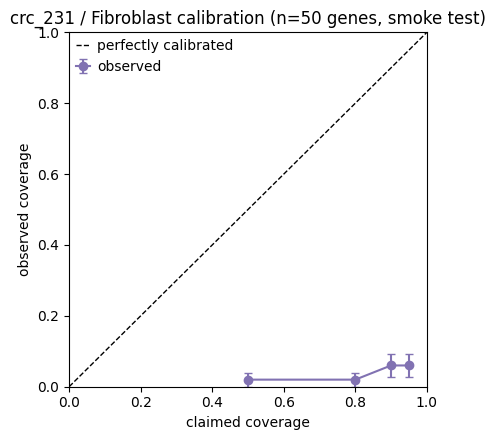

In [69]:
# --------------------------------------------------------------------------
# Analysis 3: calibration (smoke test -- one task, n_deg=50 gene "trials")
# --------------------------------------------------------------------------
banner("Analysis 3: calibration (smoke test)")

calib_rows = []
for level in CALIB_LEVELS:
    alpha = 1 - level
    #lo = np.quantile(niche_level_logfc[:, deg], alpha / 2, axis=0)
    #hi = np.quantile(niche_level_logfc[:, deg], 1 - alpha / 2, axis=0)
    lo = np.quantile(niche_level_logfc_total[:, deg], alpha / 2, axis=0)
    hi = np.quantile(niche_level_logfc_total[:, deg], 1 - alpha / 2, axis=0)

    covered = (gt_vec[deg] >= lo) & (gt_vec[deg] <= hi)
    coverage = covered.mean()
    se = np.sqrt(coverage * (1 - coverage) / N_DEG)  # binomial SE with n_deg correlated "trials"
    calib_rows.append({"claimed": level, "observed": coverage, "se_naive_binomial": se})
    print(f"  claimed {level:.0%} -> observed {coverage:.0%} "
          f"(naive binomial SE ~{se:.2f}, an optimistic lower bound given gene correlation)")

calib_df = pd.DataFrame(calib_rows)
fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="perfectly calibrated")
ax.errorbar(calib_df["claimed"], calib_df["observed"], yerr=calib_df["se_naive_binomial"],
            fmt="o-", color="#8172B2", capsize=3, label="observed")
ax.set_xlabel("claimed coverage")
ax.set_ylabel("observed coverage")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title(f"{SLIDE_ID} / {HOLDOUT_CELLTYPE} calibration (n={N_DEG} genes, smoke test)")
ax.legend()
plt.tight_layout()
plt.show()
#fig.savefig(os.path.join(FIGURES_DIR, f"{SLIDE_ID}_{HOLDOUT_CELLTYPE}_calibration.png"), dpi=200)
plt.close(fig)


Analysis 4: triage utility of sigma (smoke test, all genes)
raw Spearman(sigma, error)                         = -0.274 (p=8.59e-36)
partial Spearman(sigma, error | |gt_lfc| removed)  = -0.272 (p=2.68e-35)
(partial correlation controls for the effect-size confound: big-effect genes tend to have both big sigma and big error, which can fake a good raw correlation.)


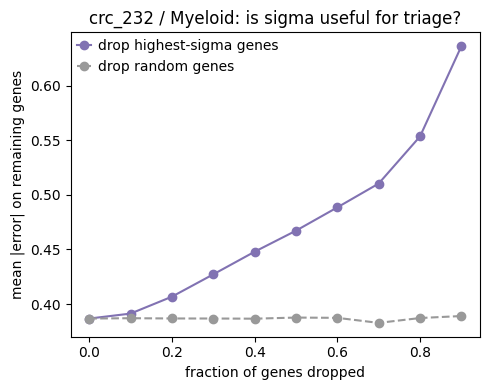

In [33]:
# --------------------------------------------------------------------------
# Analysis 4: is sigma useful for triage even if miscalibrated? (smoke test)
# --------------------------------------------------------------------------
banner("Analysis 4: triage utility of sigma (smoke test, all genes)")

#sigma_gene = niche_level_logfc.std(axis=0, ddof=1)                       # (n_genes,)
#mean_pred_gene = niche_level_logfc.mean(axis=0)
sigma_gene = niche_level_logfc_total.std(axis=0, ddof=1)
mean_pred_gene = niche_level_logfc_total.mean(axis=0)
error_gene = np.abs(gt_vec - mean_pred_gene)                              # (n_genes,)
effect_size_gene = np.abs(gt_vec)

raw_rho, raw_p = spearmanr(sigma_gene, error_gene)


def residualize(y, x):
    slope, intercept, _, _, _ = linregress(x, y)
    return y - (slope * x + intercept)


sigma_resid = residualize(sigma_gene, effect_size_gene)
error_resid = residualize(error_gene, effect_size_gene)
partial_rho, partial_p = spearmanr(sigma_resid, error_resid)

print(f"raw Spearman(sigma, error)                         = {raw_rho:.3f} (p={raw_p:.2e})")
print(f"partial Spearman(sigma, error | |gt_lfc| removed)  = {partial_rho:.3f} (p={partial_p:.2e})")
print("(partial correlation controls for the effect-size confound: big-effect genes tend to have "
      "both big sigma and big error, which can fake a good raw correlation.)")

drop_fracs = np.linspace(0.0, 0.9, 10)
n_genes = len(sigma_gene)
sigma_order = np.argsort(-sigma_gene)  # most uncertain first
n_random_reps = 50

triage_rows = []
for frac in drop_fracs:
    n_drop = int(frac * n_genes)
    kept_sigma = sigma_order[n_drop:]
    err_sigma = error_gene[kept_sigma].mean()

    random_errs = []
    for _ in range(n_random_reps):
        perm = RNG.permutation(n_genes)
        kept_rand = perm[n_drop:]
        random_errs.append(error_gene[kept_rand].mean())
    err_random = float(np.mean(random_errs))

    triage_rows.append({"drop_fraction": frac, "mean_error_drop_high_sigma": err_sigma,
                         "mean_error_drop_random": err_random})

triage_df = pd.DataFrame(triage_rows)
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(triage_df["drop_fraction"], triage_df["mean_error_drop_high_sigma"], "o-",
        color="#8172B2", label="drop highest-sigma genes")
ax.plot(triage_df["drop_fraction"], triage_df["mean_error_drop_random"], "o--",
        color="#999999", label="drop random genes")
ax.set_xlabel("fraction of genes dropped")
ax.set_ylabel("mean |error| on remaining genes")
ax.set_title(f"{SLIDE_ID} / {HOLDOUT_CELLTYPE}: is sigma useful for triage?")
ax.legend()
plt.tight_layout()
plt.show()
#fig.savefig(os.path.join(FIGURES_DIR, f"{SLIDE_ID}_{HOLDOUT_CELLTYPE}_triage.png"), dpi=200)
plt.close(fig)

In [34]:
# --------------------------------------------------------------------------
# Analysis 5: split-conformal correction (smoke test, gene split)
# --------------------------------------------------------------------------
banner("Analysis 5: conformal recalibration (smoke test)")

TARGET_LEVEL = 0.9
all_gene_idx = RNG.permutation(n_genes)
n_calib = n_genes // 2
calib_genes, test_genes = all_gene_idx[:n_calib], all_gene_idx[n_calib:]

sigma_safe = np.clip(sigma_gene, 1e-8, None)
nonconformity = np.abs(gt_vec - mean_pred_gene) / sigma_safe

q_rank = int(np.ceil((n_calib + 1) * TARGET_LEVEL)) - 1
q_rank = min(max(q_rank, 0), n_calib - 1)
q_hat = float(np.sort(nonconformity[calib_genes])[q_rank])

alpha = 1 - TARGET_LEVEL
#z_level = np.quantile(niche_level_logfc[:, test_genes], [alpha / 2, 1 - alpha / 2], axis=0)
z_level = np.quantile(niche_level_logfc_total[:, test_genes], [alpha / 2, 1 - alpha / 2], axis=0)
raw_covered = (gt_vec[test_genes] >= z_level[0]) & (gt_vec[test_genes] <= z_level[1])
raw_coverage = raw_covered.mean()

widened_lo = mean_pred_gene[test_genes] - q_hat * sigma_safe[test_genes]
widened_hi = mean_pred_gene[test_genes] + q_hat * sigma_safe[test_genes]
conformal_covered = (gt_vec[test_genes] >= widened_lo) & (gt_vec[test_genes] <= widened_hi)
conformal_coverage = conformal_covered.mean()

print(f"target level: {TARGET_LEVEL:.0%}  (calibration genes n={n_calib}, test genes n={n_genes - n_calib})")
print(f"conformal widening factor q_hat = {q_hat:.2f}")
print(f"raw (empirical-quantile) coverage on test genes      = {raw_coverage:.1%}")
print(f"conformal (widened, sigma-scaled) coverage on test genes = {conformal_coverage:.1%}")
print("Note: this is a single-task, gene-split smoke test. The plan's actual conformal "
      "correction calibrates q on OTHER cell types/slides where the answer is known, then "
      "applies it here -- that requires the Phase 2 sweep, not this one task.")


Analysis 5: conformal recalibration (smoke test)
target level: 90%  (calibration genes n=1000, test genes n=1000)
conformal widening factor q_hat = 5.19
raw (empirical-quantile) coverage on test genes      = 43.3%
conformal (widened, sigma-scaled) coverage on test genes = 88.1%
Note: this is a single-task, gene-split smoke test. The plan's actual conformal correction calibrates q on OTHER cell types/slides where the answer is known, then applies it here -- that requires the Phase 2 sweep, not this one task.


In [35]:
# --------------------------------------------------------------------------
# Summary
# --------------------------------------------------------------------------
banner("Summary")

summary = {
    "slide_id": SLIDE_ID,
    "holdout_celltype": HOLDOUT_CELLTYPE,
    "control_domain": control_domain,
    "target_domain": holdout_domain,
    "n_deg": N_DEG,
    "n_niches": N_NICHES,
    "n_zs_per_niche": N_ZS_PER_NICHE,
    "s1_pass": bool(s1_pass),
    "s1_max_abs_diff": s1_max_abs_diff,
    "single_draw_pearson_r": float(reference_pear),
    "s2_spread_ratio_varying_over_frozen": float(s2_ratio),
    "variance_share_niche_choice": props["niche_choice"],
    "variance_share_z_s_latents": props["z_s_latents"],
    "variance_share_nb_noise": props["nb_emission_noise"],
    "a2_spearman_sigma_vs_distance": float(rho_sigma_dist),
    "a2_spearman_sigma_vs_distance_pvalue": float(p_sigma_dist),
    "a4_raw_spearman_sigma_error": float(raw_rho),
    "a4_partial_spearman_sigma_error": float(partial_rho),
    "a5_conformal_q_hat": q_hat,
    "a5_raw_coverage_at_90": float(raw_coverage),
    "a5_conformal_coverage_at_90": float(conformal_coverage),
}
for k, v in summary.items():
    print(f"  {k}: {v}")

#with open(os.path.join(RESULTS_DIR, f"{SLIDE_ID}_{HOLDOUT_CELLTYPE}_summary.json"), "w") as fh:
#    json.dump(summary, fh, indent=2)
#calib_df.to_csv(os.path.join(RESULTS_DIR, f"{SLIDE_ID}_{HOLDOUT_CELLTYPE}_calibration.csv"), index=False)
#triage_df.to_csv(os.path.join(RESULTS_DIR, f"{SLIDE_ID}_{HOLDOUT_CELLTYPE}_triage.csv"), index=False)

print(f"\nSaved summary to {RESULTS_DIR}")
print(f"Saved figures to {FIGURES_DIR}")


Summary
  slide_id: crc_232
  holdout_celltype: Myeloid
  control_domain: REF
  target_domain: CRC
  n_deg: 50
  n_niches: 20
  n_zs_per_niche: 6
  s1_pass: True
  s1_max_abs_diff: 0.0
  single_draw_pearson_r: 0.8998671836352283
  s2_spread_ratio_varying_over_frozen: 2.3321340858293276
  variance_share_niche_choice: 8.922716340018995e-05
  variance_share_z_s_latents: 9.582608895633228e-05
  variance_share_nb_noise: 0.9998149467476435
  a2_spearman_sigma_vs_distance: 0.07767388561092425
  a2_spearman_sigma_vs_distance_pvalue: 0.012517329098509134
  a4_raw_spearman_sigma_error: -0.274067176016794
  a4_partial_spearman_sigma_error: -0.27214982003745497
  a5_conformal_q_hat: 5.1912041313421815
  a5_raw_coverage_at_90: 0.433
  a5_conformal_coverage_at_90: 0.881

Saved summary to /data/a330d/projects/cellina-reproducibility/results/uncertainty
Saved figures to /data/a330d/projects/cellina-reproducibility/figures/uncertainty
